## ML Project

#### 🏭 Industry  
- Marketing & Media  

#### 🌐 Domain  
- Lifestyle & Consumer Themes  

## 📂 Dataset Information

#### 🔎 Sources
- **GDELT GKG** (Global Knowledge Graph)  
- **Google Trends**  
Both datasets are **open source** and publicly available.  
- ✅ No privacy, licensing, or access restrictions  
- ✅ Safe for research and academic use 

## Loading the Datasets

In [192]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import mysql.connector
from colorama import Fore, Style
from warnings import filterwarnings
filterwarnings("ignore")

In [62]:
# connecting to the MySQL database
connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="!@Mstrong@1234",
    database="GDELTTrends"
)

In [63]:
# initializing the cursor to execute SQL queries
cursor = connection.cursor()

In [64]:
# getting table names from the database
cursor.execute("SHOW TABLES")

In [65]:
print("Tables in GDELTTrends:")
for table in cursor.fetchall():
    print(table[0])

Tables in GDELTTrends:
gdelt_gkg
google_trends
merged_data


In [66]:
gkg = pd.read_sql("SELECT * FROM gdelt_gkg;", connection)
gtrends = pd.read_sql("SELECT * FROM google_trends;", connection)

In [67]:
gkg.head()

,Week_Start,Country_Code,Category,Media_Volume,tone_net_sentiment,tone_positive_score,tone_negative_score,tone_polarity,tone_activity_density,tone_self_group_density,Source_Diversity
0,2023-01-01,AE,Fashion_Beauty,115,1.401100,4.34705,2.94595,7.29301,21.0569,0.618644,81
1,2023-01-01,AE,Fitness_Wearables,52,-1.598140,3.93978,5.53792,9.47770,18.9000,0.208290,44
2,2023-01-01,AE,Nutrition_Diets,845,1.083790,4.18150,3.09772,7.27922,20.7641,0.583760,329
3,2023-01-01,AU,Fashion_Beauty,172,-1.462470,2.71911,4.18158,6.90069,19.9640,0.394380,144
4,2023-01-01,AU,Fitness_Wearables,13,0.996642,3.45307,2.45642,5.90949,21.0787,0.929115,13


In [68]:
gtrends.head()

,Week_Start,Country_Code,Country_Name,Category,Search_Interest,Search_Velocity,Search_Acceleration
0,2023-01-01,AE,United_Arab_Emirates,Fashion_Beauty,67.23,-13.20,-4.62
1,2023-01-01,AE,United_Arab_Emirates,Fitness_Wearables,72.78,5.97,12.48
2,2023-01-01,AE,United_Arab_Emirates,Nutrition_Diets,74.40,14.84,23.46
3,2023-01-01,AU,Australia,Fashion_Beauty,58.06,-12.50,5.27
4,2023-01-01,AU,Australia,Fitness_Wearables,89.21,25.64,39.61


In [69]:
gkg['Week_Start'] = pd.to_datetime(gkg['Week_Start'], format='%Y-%m-%d')

In [70]:
mergerd_data = pd.merge(gtrends, gkg, on=['Week_Start','Country_Code','Category'], how='left')

In [71]:
mergerd_data.head()

,Week_Start,Country_Code,Country_Name,Category,Search_Interest,Search_Velocity,Search_Acceleration,Media_Volume,tone_net_sentiment,tone_positive_score,tone_negative_score,tone_polarity,tone_activity_density,tone_self_group_density,Source_Diversity
0,2023-01-01,AE,United_Arab_Emirates,Fashion_Beauty,67.23,-13.20,-4.62,115.0,1.401100,4.34705,2.94595,7.29301,21.0569,0.618644,81.0
1,2023-01-01,AE,United_Arab_Emirates,Fitness_Wearables,72.78,5.97,12.48,52.0,-1.598140,3.93978,5.53792,9.47770,18.9000,0.208290,44.0
2,2023-01-01,AE,United_Arab_Emirates,Nutrition_Diets,74.40,14.84,23.46,845.0,1.083790,4.18150,3.09772,7.27922,20.7641,0.583760,329.0
3,2023-01-01,AU,Australia,Fashion_Beauty,58.06,-12.50,5.27,172.0,-1.462470,2.71911,4.18158,6.90069,19.9640,0.394380,144.0
4,2023-01-01,AU,Australia,Fitness_Wearables,89.21,25.64,39.61,13.0,0.996642,3.45307,2.45642,5.90949,21.0787,0.929115,13.0


In [72]:
mergerd_data['Country_Name'].unique()

array(['United_Arab_Emirates', 'Australia', 'Brazil', 'Canada', 'China',
       'Germany', 'France', 'United_Kingdom', 'India', 'Japan', 'Kenya',
       'Mexico', 'Nigeria', 'Singapore', 'United_States', 'South_Africa'],
      dtype=object)

In [73]:
mergerd_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9168 entries, 0 to 9167
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Week_Start               9168 non-null   datetime64[ns]
 1   Country_Code             9168 non-null   object        
 2   Country_Name             9168 non-null   object        
 3   Category                 9168 non-null   object        
 4   Search_Interest          9168 non-null   float64       
 5   Search_Velocity          9168 non-null   float64       
 6   Search_Acceleration      9168 non-null   float64       
 7   Media_Volume             7725 non-null   float64       
 8   tone_net_sentiment       7725 non-null   float64       
 9   tone_positive_score      7725 non-null   float64       
 10  tone_negative_score      7725 non-null   float64       
 11  tone_polarity            7725 non-null   float64       
 12  tone_activity_density    7725 non-

In [74]:
mergerd_data.columns

Index(['Week_Start', 'Country_Code', 'Country_Name', 'Category',
       'Search_Interest', 'Search_Velocity', 'Search_Acceleration',
       'Media_Volume', 'tone_net_sentiment', 'tone_positive_score',
       'tone_negative_score', 'tone_polarity', 'tone_activity_density',
       'tone_self_group_density', 'Source_Diversity'],
      dtype='object')

## Data Validation

In [75]:
# Required columns/features present?
mergerd_data.columns


Index(['Week_Start', 'Country_Code', 'Country_Name', 'Category',
       'Search_Interest', 'Search_Velocity', 'Search_Acceleration',
       'Media_Volume', 'tone_net_sentiment', 'tone_positive_score',
       'tone_negative_score', 'tone_polarity', 'tone_activity_density',
       'tone_self_group_density', 'Source_Diversity'],
      dtype='object')

In [76]:
# Country_name is enough Country_code is not required. So, dropping the country code column.
#mergerd_data = mergerd_data.drop(columns=['Country_Code'])

## ✨ Creating Features

#### 📈 Demand_to_Hype_Ratio  
- **Definition:** Consumer demand (search intent) relative to media volume  
- **Purpose:** Detect whether demand is organic or inflated by media hype  

---

#### 📰 Media_Volume_per_Source  
- **Definition:** Media coverage normalized by source diversity  
- **Purpose:** Measure how concentrated or distributed coverage is across sources  

---

#### 🔍 Interest_per_Source  
- **Definition:** Search demand relative to source count  
- **Purpose:** Identify whether high demand is supported by broad media coverage or limited sources  


In [77]:
df1 = mergerd_data

In [78]:
## Calculating Demand to Hype Ratio
df1['Demand_to_Hype_Ratio'] = (df1['Search_Interest'] /(df1['Media_Volume'] + 1))

In [79]:
df1['Media_Volume_per_Source'] = (df1['Media_Volume'] / (df1['Source_Diversity']))

In [80]:
df1['Interest_per_Source'] = (df1['Search_Interest'] / (df1['Source_Diversity']))

In [81]:
corr = df1.corr(numeric_only=True)

In [82]:
df1.columns

Index(['Week_Start', 'Country_Code', 'Country_Name', 'Category',
       'Search_Interest', 'Search_Velocity', 'Search_Acceleration',
       'Media_Volume', 'tone_net_sentiment', 'tone_positive_score',
       'tone_negative_score', 'tone_polarity', 'tone_activity_density',
       'tone_self_group_density', 'Source_Diversity', 'Demand_to_Hype_Ratio',
       'Media_Volume_per_Source', 'Interest_per_Source'],
      dtype='object')

In [83]:
df1.head()

,Week_Start,Country_Code,Country_Name,Category,Search_Interest,Search_Velocity,Search_Acceleration,Media_Volume,tone_net_sentiment,tone_positive_score,tone_negative_score,tone_polarity,tone_activity_density,tone_self_group_density,Source_Diversity,Demand_to_Hype_Ratio,Media_Volume_per_Source,Interest_per_Source
0,2023-01-01,AE,United_Arab_Emirates,Fashion_Beauty,67.23,-13.20,-4.62,115.0,1.401100,4.34705,2.94595,7.29301,21.0569,0.618644,81.0,0.579569,1.419753,0.830000
1,2023-01-01,AE,United_Arab_Emirates,Fitness_Wearables,72.78,5.97,12.48,52.0,-1.598140,3.93978,5.53792,9.47770,18.9000,0.208290,44.0,1.373208,1.181818,1.654091
2,2023-01-01,AE,United_Arab_Emirates,Nutrition_Diets,74.40,14.84,23.46,845.0,1.083790,4.18150,3.09772,7.27922,20.7641,0.583760,329.0,0.087943,2.568389,0.226140
3,2023-01-01,AU,Australia,Fashion_Beauty,58.06,-12.50,5.27,172.0,-1.462470,2.71911,4.18158,6.90069,19.9640,0.394380,144.0,0.335607,1.194444,0.403194
4,2023-01-01,AU,Australia,Fitness_Wearables,89.21,25.64,39.61,13.0,0.996642,3.45307,2.45642,5.90949,21.0787,0.929115,13.0,6.372143,1.000000,6.862308


## ✅ Feature Engineering Status

#### 📊 Summary
- Created sufficient columns for analysis  
- All **required features** and supporting columns are present, if any required will be **created later**.

####  Valid and Realistic Values in the Columns

In [ ]:

cat_cols = mergerd_data.select_dtypes(include=object).columns

In [116]:
num_cols = mergerd_data.select_dtypes(include=['float64', 'int64']).columns

In [117]:
for col in cat_cols:
    print(f"{col}:")
    print(f"Number of unique values in '{col}': {len(mergerd_data[col].unique())}\n")
    print(f"Unique values in '{col}': {mergerd_data[col].unique()}\n")
    

Country_Code:
Number of unique values in 'Country_Code': 16

Unique values in 'Country_Code': ['AE' 'AU' 'BR' 'CA' 'CN' 'DE' 'FR' 'GB' 'IN' 'JP' 'KE' 'MX' 'NG' 'SG'
 'US' 'ZA']

Country_Name:
Number of unique values in 'Country_Name': 16

Unique values in 'Country_Name': ['United_Arab_Emirates' 'Australia' 'Brazil' 'Canada' 'China' 'Germany'
 'France' 'United_Kingdom' 'India' 'Japan' 'Kenya' 'Mexico' 'Nigeria'
 'Singapore' 'United_States' 'South_Africa']

Category:
Number of unique values in 'Category': 3

Unique values in 'Category': ['Fashion_Beauty' 'Fitness_Wearables' 'Nutrition_Diets']



In [118]:
for col in cat_cols:
    unique_count = mergerd_data[col].nunique()
    unique_values = mergerd_data[col].unique()
    print(f"Number of unique values in '{col}': {unique_count}")
    display(pd.DataFrame({"Names": unique_values},index=range(1, len(unique_values) + 1)))

Number of unique values in 'Country_Code': 16


,Names
1,AE
2,AU
3,BR
4,CA
5,CN
6,DE
7,FR
8,GB
9,IN
10,JP


Number of unique values in 'Country_Name': 16


,Names
1,United_Arab_Emirates
2,Australia
3,Brazil
4,Canada
5,China
6,Germany
7,France
8,United_Kingdom
9,India
10,Japan


Number of unique values in 'Category': 3


,Names
1,Fashion_Beauty
2,Fitness_Wearables
3,Nutrition_Diets


In [119]:
mergerd_data.describe()

,Week_Start,Search_Interest,Search_Velocity,Search_Acceleration,Media_Volume,tone_net_sentiment,tone_positive_score,tone_negative_score,tone_polarity,tone_activity_density,tone_self_group_density,Source_Diversity,Demand_to_Hype_Ratio,Media_Volume_per_Source,Interest_per_Source
count,9168,9168.000000,9168.000000,9168.000000,7725.000000,7725.000000,7725.000000,7725.000000,7725.000000,7725.000000,7725.000000,7725.000000,7725.000000,7725.000000,7725.000000
mean,2024-10-27 00:00:00,59.570142,-0.030518,0.031242,4951.525566,-0.224535,3.422307,3.646842,7.069150,20.985827,0.584744,813.613074,1.773319,2.570941,2.870058
min,2023-01-01 00:00:00,3.160000,-69.100000,-90.690000,1.000000,-9.980800,0.218818,0.000000,1.162790,11.392400,0.000000,1.000000,0.000326,1.000000,0.004216
25%,2023-11-26 00:00:00,48.302500,-1.990000,-2.900000,43.000000,-1.435080,2.955820,2.889070,6.403830,19.976700,0.427160,30.000000,0.032041,1.378378,0.093975
50%,2024-10-27 00:00:00,64.380000,-0.110000,0.130000,282.000000,-0.317332,3.245330,3.690930,7.093670,21.018200,0.552333,146.000000,0.235993,1.793103,0.444176
75%,2025-09-28 00:00:00,73.990000,1.890000,3.142500,1969.000000,0.735335,3.762470,4.483570,7.709740,22.170800,0.718370,673.000000,1.512245,2.771739,2.222941
max,2026-08-23 00:00:00,100.000000,43.390000,74.170000,168862.000000,10.319000,11.155700,11.802400,13.924100,31.606500,3.898570,12317.000000,47.645000,19.980392,95.290000
std,NaN,20.544332,5.137408,7.387023,18238.421349,1.689364,0.763623,1.179626,1.046579,1.949319,0.271650,1760.765126,4.215094,2.125809,7.675287


### 🌟 Valid and Realistic Values in the Columns

---

### ✅ Overview
- All feature columns contain **valid ranges** consistent with their definitions  
- No unrealistic or out‑of‑scope values detected  

---

### 📊 Value Ranges

| 🏷️ Feature              | 📐 Theoretical Range                  | 🌍 Real-World Range         |
|--------------------------|---------------------------------------|-----------------------------|
| **Search_Interest**      | 0.0 → 100.0                          | 3.0 → 100.0                 |
| **Media_Volume**         | 0 → ∞                                | 1 → 168,862+                |
| **tone_net_sentiment**   | −100.0 → +100.0                      | −10.0 → +10.0               |
| **tone_positive_score**  | 0.0% → 100.0%                        | 0.2% → 11.2%                |
| **tone_negative_score**  | 0.0% → 100.0%                        | 0.0% → 11.8%                |
| **tone_polarity**        | 0.0% → 100.0%                        | 1.1% → 13.9%                |
| **tone_activity_density**| 0.0% → 100.0%                        | 11.3% → 31.6%               |
| **tone_self_group_density** | 0.0% → 100.0%                     | 0.0% → 3.9%                 |
| **Source_Diversity**     | 1 → ∞                                | 1 → 12,317+                 |
 

## Reliable Labels?

In [89]:
# Reliable Labels?
cols = mergerd_data.columns
print(cols)

Index(['Week_Start', 'Country_Code', 'Country_Name', 'Category',
       'Search_Interest', 'Search_Velocity', 'Search_Acceleration',
       'Media_Volume', 'tone_net_sentiment', 'tone_positive_score',
       'tone_negative_score', 'tone_polarity', 'tone_activity_density',
       'tone_self_group_density', 'Source_Diversity', 'Demand_to_Hype_Ratio',
       'Media_Volume_per_Source', 'Interest_per_Source'],
      dtype='object')


### ✅  no Problem with the labels

## Correct DataTypes?

In [182]:
mergerd_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9168 entries, 0 to 9167
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Week_Start               9168 non-null   datetime64[ns]
 1   Country_Code             9168 non-null   object        
 2   Country_Name             9168 non-null   object        
 3   Category                 9168 non-null   object        
 4   Search_Interest          9168 non-null   float64       
 5   Search_Velocity          9168 non-null   float64       
 6   Search_Acceleration      9168 non-null   float64       
 7   Media_Volume             7725 non-null   float64       
 8   tone_net_sentiment       7725 non-null   float64       
 9   tone_positive_score      7725 non-null   float64       
 10  tone_negative_score      7725 non-null   float64       
 11  tone_polarity            7725 non-null   float64       
 12  tone_activity_density    7725 non-

In [91]:
# Week_Start is a date column, so converting it to datetime format.
mergerd_data['Week_Start'] = pd.to_datetime(mergerd_data['Week_Start'])

### ✅ All datatypes are correct, No problem with datatypes

### 📊 Enough Data

<span style="font-size:16px; font-weight:bold; color:green">
✔ Data covers <b>14 countries</b>, <b>3 categories</b>, and <b>191 weeks</b>  
(~3.7 years of continuous observations)
</span>

<span style="font-size:15px; color:blue">
📈 Total Rows: <b>9,168</b>
</span>


In [92]:
# missing values or Duplicates in the dataset?
mergerd_data.isnull().sum()

Week_Start                    0
Country_Code                  0
Country_Name                  0
Category                      0
Search_Interest               0
Search_Velocity               0
Search_Acceleration           0
Media_Volume               1443
tone_net_sentiment         1443
tone_positive_score        1443
tone_negative_score        1443
tone_polarity              1443
tone_activity_density      1443
tone_self_group_density    1443
Source_Diversity           1443
Demand_to_Hype_Ratio       1443
Media_Volume_per_Source    1443
Interest_per_Source        1443
dtype: int64

In [93]:
mergerd_data.duplicated().sum()

np.int64(0)

In [181]:
# Filter out 'JP' and 'DE' using Country_Code
df_filtered = mergerd_data[~mergerd_data['Country_Code'].isin(['JP', 'DE'])].reset_index(
    drop=True
)
# Verify the updated row count and remaining countries
print(f"Original Row Count : {len(mergerd_data):,}")
print(f"Filtered Row Count : {len(df_filtered):,}")
print(
    f"\nRemaining Countries ({df_filtered['Country_Code'].nunique()} total):"
)
print(sorted(df_filtered['Country_Code'].unique()))
# Save the cleaned dataset
df_filtered.to_csv("master_market_dataset_14countries.csv", index=False)

Original Row Count : 9,168
Filtered Row Count : 8,022

Remaining Countries (14 total):
['AE', 'AU', 'BR', 'CA', 'CN', 'FR', 'GB', 'IN', 'KE', 'MX', 'NG', 'SG', 'US', 'ZA']


## 📊 Data Validation Summary: Google Trends + GDELT GKG

- **Join Type:** Left Join  
- **Dataset Sizes:**  
  - Google Trends → **9168 records**  
  - GDELT GKG → **7725 records**
  - Merged and filtered → **8022 records**
---

### 🔎 Null Value Analysis
- <span style="color:red; font-weight:bold">Total NULL values: 1443</span>  
  *(all columns related to GDELT GKG)*  

- <span style="color:orange; font-weight:bold">Total NULL values after removing Japan & Germany: 1,146</span>  

---
### 🌍 Coverage
- **Countries:** <span style="color:purple; font-weight:bold">14</span>  
  *(AE, AU, BR, CA, CN, FR, GB, IN, KE, MX, NG, SG, US, ZA)*  
- **Categories:** <span style="color:purple; font-weight:bold">3</span> (Lifestyle & Consumer Themes)  
- **Time Span:** <span style="color:purple; font-weight:bold">191 weeks (~3.7 years)</span>  

---
### 🔎 Data Quality
- <span style="color:red; font-weight:bold">Null Values (initial): 1,433</span>  
  *(all GDELT columns)*  
- <span style="color:orange; font-weight:bold">Null Values (after removing Japan & Germany): 1,146</span>  
- **Labels:** Reliable (open‑source datasets)  
- **Restrictions:** None (publicly available, safe for research use)  

---
### ✅ Readiness
- Required features and engineered columns are present  
- Values are valid and realistic  
- Dataset is ready for <span style="color:green; font-weight:bold"> Exploratory Data Analysis</span>  


# Data Undetstanding & EDA

In [95]:
# assigning the merged data to df1 for further analysis
df1 = df_filtered

In [96]:
num_cols = df1.select_dtypes(include=['float64', 'int64']).columns
print(num_cols)

Index(['Search_Interest', 'Search_Velocity', 'Search_Acceleration',
       'Media_Volume', 'tone_net_sentiment', 'tone_positive_score',
       'tone_negative_score', 'tone_polarity', 'tone_activity_density',
       'tone_self_group_density', 'Source_Diversity', 'Demand_to_Hype_Ratio',
       'Media_Volume_per_Source', 'Interest_per_Source'],
      dtype='object')


# UNIVARIATE ANALYSIS

In [97]:
start_week =df1['Week_Start'].min().strftime('%Y-%m-%d')
End_week = df1['Week_Start'].max().strftime('%Y-%m-%d')

In [98]:
cat_cols = df1.select_dtypes(include=['object']).columns

In [99]:
print(cat_cols)

Index(['Country_Code', 'Country_Name', 'Category'], dtype='object')


In [100]:
# statiscal analysis of the categorical columns in the dataset, for checking class imbalance
def analyze_cat_column(df, column):
    value_counts = df[column].value_counts()
    total_count = len(df)
    percentage = (value_counts / total_count) * 100

    analysis_df = pd.DataFrame({
        'Name': value_counts.index,
        'Count': value_counts.values,
        'Percentage': percentage.values
    }, index=range(1, len(value_counts) + 1))

    return analysis_df

In [101]:
analyze_cat_column(df1, 'Category')

,Name,Count,Percentage
1,Fashion_Beauty,2674,33.333333
2,Fitness_Wearables,2674,33.333333
3,Nutrition_Diets,2674,33.333333


In [102]:
print(f"Descriptive Summary of 'Country_Name' ({start_week} to {End_week}):")
print("Number of unique values in 'Country_Name':", len(df1['Country_Name'].unique()))
print("\nDistribution of 'Country_Name':")
display(analyze_cat_column(df1, 'Country_Name'))

Descriptive Summary of 'Country_Name' (2023-01-01 to 2026-08-23):
Number of unique values in 'Country_Name': 14

Distribution of 'Country_Name':


,Name,Count,Percentage
1,United_Arab_Emirates,573,7.142857
2,Australia,573,7.142857
3,Brazil,573,7.142857
4,Canada,573,7.142857
5,China,573,7.142857
6,France,573,7.142857
7,United_Kingdom,573,7.142857
8,India,573,7.142857
9,Kenya,573,7.142857
10,Mexico,573,7.142857


In [103]:
# function to analyze distribution of numerical columns(Descriptive Statistics)
def analyze_distribution(df, column):
    print(f"Descriptive Summary of {column} ({start_week} to {End_week}):")
    print("="*70)
    range = df[column].max() - df[column].min()
    min_value = df[column].min()
    max_value = df[column].max()
    print(f"Range: {range}")
    print(f"Min - Max: ({min_value} - {max_value})")
    mean_value = df[column].mean()
    print(f"Mean: {mean_value}")
    median_value = df[column].median()
    print(f"Median: {median_value}")
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    print(f"Q1: {q1}, Q3: {q3}")
    IQR = q3 - q1
    print(f"IQR: {IQR}")
    std_value = df[column].std()
    print(f"Standard Deviation: {std_value}")
    skewness_value = df[column].skew()
    print(f"Skewness: {skewness_value}")
    kurtosis_value = df[column].kurtosis()
    print(f"Kurtosis: {kurtosis_value}")
    missing_values = df[column].isnull().sum()
    print(f"Missing Values: {missing_values}")
    lower_outliers = len(df[column][df[column] < (q1 - 1.5 * IQR)])
    upper_outliers = len(df[column][df[column] > (q3 + 1.5 * IQR)])
    print(f"Lower Outliers: {lower_outliers}")
    print(f"Upper Outliers: {upper_outliers}")
    outliers = df[(df[column] < (q1 - 1.5 * IQR)) | (df[column] > (q3 + 1.5 * IQR))]
    print(f"Total Number of Outliers: {outliers.shape[0]}")





In [124]:
def basic_analyze(df, column):
    print("="*70)
    print(f"Descriptive Summary of {column} ({start_week} to {End_week}):")
    print("="*70)
    range = df[column].max() - df[column].min()
    min_value = df[column].min()
    max_value = df[column].max()
    print(f"Range: {range}")
    print(f"Min - Max: ({min_value} - {max_value})")
    mean_value = df[column].mean()
    print(f"Mean: {mean_value}")
    median_value = df[column].median()
    print(f"Median: {median_value}\n")

In [125]:
for col in num_cols:
    basic_analyze(df1, col)

Descriptive Summary of Search_Interest (2023-01-01 to 2026-08-23):
Range: 96.84
Min - Max: (3.16 - 100.0)
Mean: 61.828076539516324
Median: 65.88

Descriptive Summary of Search_Velocity (2023-01-01 to 2026-08-23):
Range: 95.07
Min - Max: (-51.68 - 43.39)
Mean: -0.026406133133881838
Median: -0.12

Descriptive Summary of Search_Acceleration (2023-01-01 to 2026-08-23):
Range: 164.86
Min - Max: (-90.69 - 74.17)
Mean: 0.027035651957117934
Median: 0.14

Descriptive Summary of Media_Volume (2023-01-01 to 2026-08-23):
Range: 168861.0
Min - Max: (1.0 - 168862.0)
Mean: 4951.525566343042
Median: 282.0

Descriptive Summary of tone_net_sentiment (2023-01-01 to 2026-08-23):
Range: 20.2998
Min - Max: (-9.9808 - 10.319)
Mean: -0.2245349161083495
Median: -0.317332

Descriptive Summary of tone_positive_score (2023-01-01 to 2026-08-23):
Range: 10.936881999999999
Min - Max: (0.218818 - 11.1557)
Mean: 3.4223074278317154
Median: 3.24533

Descriptive Summary of tone_negative_score (2023-01-01 to 2026-08-23):


In [104]:
# Descriptive Statistics for Search_Interest
analyze_distribution(df1, 'Search_Interest')

Descriptive Summary of Search_Interest (2023-01-01 to 2026-08-23):
Range: 96.84
Min - Max: (3.16 - 100.0)
Mean: 61.828076539516324
Median: 65.88
Q1: 52.2925, Q3: 74.66
IQR: 22.3675
Standard Deviation: 19.176093488475235
Skewness: -0.8562257427084379
Kurtosis: 0.4920945535893386
Missing Values: 0
Lower Outliers: 333
Upper Outliers: 0
Total Number of Outliers: 333


In [105]:
# Descriptive Statistics for Media_Volume
analyze_distribution(df1, 'Media_Volume')

Descriptive Summary of Media_Volume (2023-01-01 to 2026-08-23):
Range: 168861.0
Min - Max: (1.0 - 168862.0)
Mean: 4951.525566343042
Median: 282.0
Q1: 43.0, Q3: 1969.0
IQR: 1926.0
Standard Deviation: 18238.42134888198
Skewness: 5.916783777198726
Kurtosis: 35.74304825497148
Missing Values: 297
Lower Outliers: 0
Upper Outliers: 1352
Total Number of Outliers: 1352


In [106]:
# Descriptive Statistics for tone_net_sentiment
analyze_distribution(df1, 'tone_net_sentiment')

Descriptive Summary of tone_net_sentiment (2023-01-01 to 2026-08-23):
Range: 20.2998
Min - Max: (-9.9808 - 10.319)
Mean: -0.2245349161083495
Median: -0.317332
Q1: -1.43508, Q3: 0.735335
IQR: 2.1704149999999998
Standard Deviation: 1.6893641798969286
Skewness: 0.3708320407369475
Kurtosis: 1.2791426456477275
Missing Values: 297
Lower Outliers: 44
Upper Outliers: 110
Total Number of Outliers: 154


In [107]:
# Descriptive Statistics for tone_positive_score
analyze_distribution(df1, 'tone_positive_score')

Descriptive Summary of tone_positive_score (2023-01-01 to 2026-08-23):
Range: 10.936881999999999
Min - Max: (0.218818 - 11.1557)
Mean: 3.4223074278317154
Median: 3.24533
Q1: 2.95582, Q3: 3.76247
IQR: 0.8066499999999999
Standard Deviation: 0.7636234471829042
Skewness: 1.3245487750497336
Kurtosis: 5.041870517474418
Missing Values: 297
Lower Outliers: 63
Upper Outliers: 310
Total Number of Outliers: 373


In [108]:
# Descriptive Statistics for tone_negative_score
analyze_distribution(df1, 'tone_negative_score')

Descriptive Summary of tone_negative_score (2023-01-01 to 2026-08-23):
Range: 11.8024
Min - Max: (0.0 - 11.8024)
Mean: 3.6468423752750807
Median: 3.69093
Q1: 2.88907, Q3: 4.48357
IQR: 1.5945000000000005
Standard Deviation: 1.1796264129934557
Skewness: 0.1369751518968973
Kurtosis: 0.9021268245179375
Missing Values: 297
Lower Outliers: 20
Upper Outliers: 56
Total Number of Outliers: 76


In [109]:
# Descriptive Statistics for tone_polarity
analyze_distribution(df1, 'tone_polarity')

Descriptive Summary of tone_polarity (2023-01-01 to 2026-08-23):
Range: 12.76131
Min - Max: (1.16279 - 13.9241)
Mean: 7.069149825242719
Median: 7.09367
Q1: 6.40383, Q3: 7.70974
IQR: 1.30591
Standard Deviation: 1.0465789480494383
Skewness: -0.006916551371589696
Kurtosis: 2.351785417939661
Missing Values: 297
Lower Outliers: 96
Upper Outliers: 70
Total Number of Outliers: 166


In [110]:
# Descriptive Statistics for tone_activity_density
analyze_distribution(df1, 'tone_activity_density')

Descriptive Summary of tone_activity_density (2023-01-01 to 2026-08-23):
Range: 20.214100000000002
Min - Max: (11.3924 - 31.6065)
Mean: 20.985826588996762
Median: 21.0182
Q1: 19.9767, Q3: 22.1708
IQR: 2.194099999999999
Standard Deviation: 1.9493185015497165
Skewness: -0.2569777175099523
Kurtosis: 2.1695636091762864
Missing Values: 297
Lower Outliers: 165
Upper Outliers: 129
Total Number of Outliers: 294


In [111]:
# Descriptive Statistics for tone_self_group_density
analyze_distribution(df1, 'tone_self_group_density')

Descriptive Summary of tone_self_group_density (2023-01-01 to 2026-08-23):
Range: 3.89857
Min - Max: (0.0 - 3.89857)
Mean: 0.5847441430032363
Median: 0.552333
Q1: 0.42716, Q3: 0.71837
IQR: 0.29120999999999997
Standard Deviation: 0.2716501992262028
Skewness: 2.1943650917599022
Kurtosis: 14.920721498235258
Missing Values: 297
Lower Outliers: 0
Upper Outliers: 182
Total Number of Outliers: 182


In [112]:
# Descriptive Statistics for Source_Diversity
analyze_distribution(df1, 'Source_Diversity')

Descriptive Summary of Source_Diversity (2023-01-01 to 2026-08-23):
Range: 12316.0
Min - Max: (1.0 - 12317.0)
Mean: 813.613074433657
Median: 146.0
Q1: 30.0, Q3: 673.0
IQR: 643.0
Standard Deviation: 1760.7651259913198
Skewness: 3.851322287160702
Kurtosis: 16.56963997237124
Missing Values: 297
Lower Outliers: 0
Upper Outliers: 1041
Total Number of Outliers: 1041


# BiVariate Analysis

In [126]:
cols

Index(['Week_Start', 'Country_Code', 'Country_Name', 'Category',
       'Search_Interest', 'Search_Velocity', 'Search_Acceleration',
       'Media_Volume', 'tone_net_sentiment', 'tone_positive_score',
       'tone_negative_score', 'tone_polarity', 'tone_activity_density',
       'tone_self_group_density', 'Source_Diversity', 'Demand_to_Hype_Ratio',
       'Media_Volume_per_Source', 'Interest_per_Source'],
      dtype='object')

In [183]:
# correlation between numerical columns
num_corr = df1[num_cols].corr()


In [135]:
import pandas as pd

# Example correlation matrix
corr = df1.corr(numeric_only=True)

# Flattened dictionary without repeats
corr_dict = {
    f"{col1} - {col2}": corr.loc[col1, col2]
    for i, col1 in enumerate(corr.columns)
    for j, col2 in enumerate(corr.columns)
    if j > i   # ensures no repeats and skips self-correlation
}

corr_df = pd.DataFrame(list(corr_dict.items()), columns=['Pair', 'Correlation'])


In [193]:
corr_dict

{'Search_Interest - Search_Velocity': np.float64(0.13138756586071879),
 'Search_Interest - Search_Acceleration': np.float64(0.006419130078122994),
 'Search_Interest - Media_Volume': np.float64(-0.09420462589534315),
 'Search_Interest - tone_net_sentiment': np.float64(0.2230888046851482),
 'Search_Interest - tone_positive_score': np.float64(0.250813692237303),
 'Search_Interest - tone_negative_score': np.float64(-0.15712686843415263),
 'Search_Interest - tone_polarity': np.float64(0.005901385134714805),
 'Search_Interest - tone_activity_density': np.float64(0.04313084766536411),
 'Search_Interest - tone_self_group_density': np.float64(0.07223858055272984),
 'Search_Interest - Source_Diversity': np.float64(-0.1935502901432205),
 'Search_Interest - Demand_to_Hype_Ratio': np.float64(0.1095983600163919),
 'Search_Interest - Media_Volume_per_Source': np.float64(-0.13873672487728253),
 'Search_Interest - Interest_per_Source': np.float64(0.083046074990466),
 'Search_Velocity - Search_Accelerat

<Axes: >

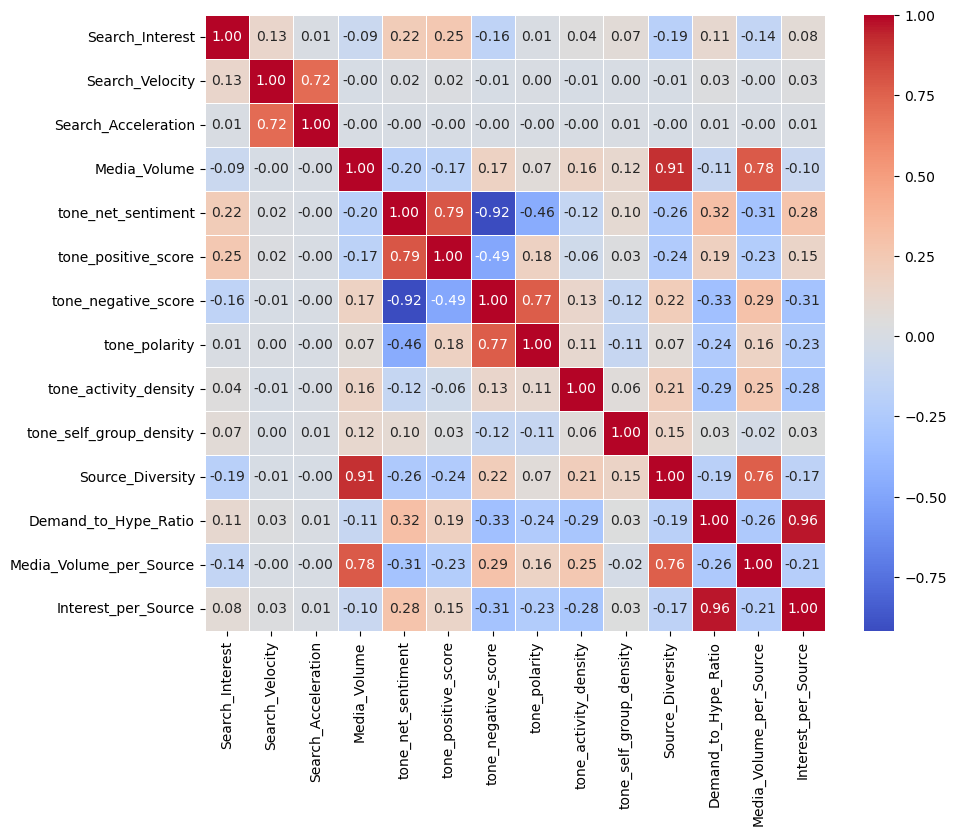

In [128]:
plt.figure(figsize=(10,8))
sns.heatmap(num_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

### 📊 Correlation Analysis Insights

#### 🔵 1. Consumer Demand & Search Momentum

- 🟡 **Search Interest ↔ Search Velocity (r = 0.131)**  
  → Current search demand has only a weak relationship with the speed at which demand is changing.

- ⚪ **Search Interest ↔ Search Acceleration (r = 0.006)**  
  → Current demand level has virtually no linear relationship with whether search momentum is accelerating or decelerating.

- 🔵 **Search Velocity ↔ Search Acceleration (r = 0.721)**  
  → Search velocity and acceleration have a strong positive relationship, indicating that periods of rapid demand movement tend to coincide with stronger changes in momentum.

💡 **Business Insight:** Search Interest, Velocity, and Acceleration capture different dimensions of demand. Current demand level alone does not explain future momentum.

---

#### 🟠 2. Consumer Demand vs Media Coverage

- 🔴 **Search Interest ↔ Media Volume (r = -0.094)**  
  → Consumer search interest and overall media coverage have almost no linear relationship.

- 🟡 **Search Interest ↔ Source Diversity (r = -0.194)**  
  → Higher search interest is weakly associated with lower source diversity.

- 🟡 **Search Interest ↔ Media Volume per Source (r = -0.139)**  
  → Higher search interest tends to be associated with slightly lower media activity per source.

- ⚪ **Search Interest ↔ Interest per Source (r = 0.083)**  
  → Search interest has almost no relationship with its source-normalized version.

💡 **Business Insight:** Consumer demand appears to operate relatively independently from the scale and breadth of media coverage.

---

#### 🟢 3. Consumer Demand & Positive/Negative Sentiment

- 🟢 **Search Interest ↔ Positive Score (r = 0.251)**  
  → Higher consumer interest has a modest positive association with positive media tone.

- 🟢 **Search Interest ↔ Net Sentiment (r = 0.223)**  
  → More positive overall media sentiment is moderately associated with higher consumer search interest.

- 🔴 **Search Interest ↔ Negative Score (r = -0.157)**  
  → Higher search interest is weakly associated with lower negative media tone.

- ⚪ **Search Interest ↔ Tone Polarity (r = 0.006)**  
  → Overall tone polarity has virtually no linear relationship with search interest.

💡 **Business Insight:** Consumer interest appears to have a somewhat stronger relationship with **positive media sentiment** than with negative sentiment or overall polarity.

---

#### 🟣 4. Search Momentum vs Media & Sentiment

- ⚪ **Search Velocity ↔ Media Volume (r = -0.005)**  
  → Changes in search demand are essentially unrelated to the amount of media coverage.

- ⚪ **Search Velocity ↔ Net Sentiment (r = 0.017)**  
  → Search momentum has almost no relationship with media sentiment.

- ⚪ **Search Velocity ↔ Positive Score (r = 0.021)**  
  → Positive media tone does not meaningfully explain changes in search velocity.

- ⚪ **Search Velocity ↔ Negative Score (r = -0.011)**  
  → Negative media tone has virtually no relationship with search velocity.

- ⚪ **Search Acceleration ↔ Media Volume (r = -0.003)**  
  → Acceleration in search demand is essentially independent of media volume.

- ⚪ **Search Acceleration ↔ Net Sentiment (r = -0.001)**  
  → Search acceleration shows virtually no linear relationship with media sentiment.

💡 **Business Insight:** Media sentiment and media volume do not appear to explain short-term changes in consumer search momentum.

---

#### 🟠 5. Media Volume & Source Breadth

- 🟢 **Media Volume ↔ Source Diversity (r = 0.915)**  
  → Media volume has a very strong positive relationship with source diversity.

- 🟢 **Media Volume ↔ Media Volume per Source (r = 0.782)**  
  → Higher total media coverage is strongly associated with higher media volume per source.

- 🟡 **Media Volume ↔ Negative Score (r = 0.172)**  
  → Greater media coverage is weakly associated with more negative media tone.

- 🟡 **Media Volume ↔ Net Sentiment (r = -0.197)**  
  → Higher media volume is weakly associated with lower net sentiment.

- 🟡 **Media Volume ↔ Positive Score (r = -0.171)**  
  → Higher media volume is weakly associated with lower positive tone.

- 🟡 **Media Volume ↔ Activity Density (r = 0.156)**  
  → Greater media volume is modestly associated with higher activity density.

- 🟡 **Media Volume ↔ Self/Group Density (r = 0.120)**  
  → Media volume has a weak positive association with self/group-oriented language.

💡 **Business Insight:** Higher media coverage is associated with broader source participation, but it does **not necessarily mean more positive coverage**. In fact, greater coverage shows a slight tendency toward more negative tone.

---

#### 🔴 6. Media Volume & Demand-to-Hype Relationship

- 🟡 **Media Volume ↔ Demand-to-Hype Ratio (r = -0.113)**  
  → Higher media volume is weakly associated with a lower demand-to-hype ratio.

- 🔴 **Media Volume ↔ Interest per Source (r = -0.100)**  
  → Higher media volume is weakly associated with lower search interest relative to source breadth.

💡 **Business Insight:** Increasing media coverage does not necessarily correspond to increasing consumer demand; high media activity can occur without proportional search interest.

---

#### 🟢 7. Net Sentiment Relationships

- 🟢 **Net Sentiment ↔ Positive Score (r = 0.793)**  
  → Positive media tone strongly contributes to higher net sentiment.

- 🔴 **Net Sentiment ↔ Negative Score (r = -0.919)**  
  → Negative media tone has a very strong inverse relationship with net sentiment.

- 🟠 **Net Sentiment ↔ Tone Polarity (r = -0.457)**  
  → Net sentiment and polarity have a moderate negative relationship in this dataset.

- 🟡 **Net Sentiment ↔ Activity Density (r = -0.119)**  
  → Higher activity density is weakly associated with lower net sentiment.

- 🟡 **Net Sentiment ↔ Source Diversity (r = -0.257)**  
  → Greater source diversity is modestly associated with lower net sentiment.

💡 **Business Insight:** Negative media tone appears to have a stronger relationship with overall net sentiment than positive tone, while broader source participation is slightly associated with less favorable sentiment.

---

#### 🟣 8. Positive vs Negative Media Tone

- 🟠 **Positive Score ↔ Negative Score (r = -0.488)**  
  → Positive and negative media tone have a moderate inverse relationship.

- 🟡 **Positive Score ↔ Tone Polarity (r = 0.180)**  
  → Positive tone has only a weak relationship with polarity.

- 🟡 **Negative Score ↔ Tone Polarity (r = 0.771)**  
  → Negative tone has a strong relationship with polarity in this dataset.

⚠️ **Important EDA Check:**  
The strong positive correlation between `tone_negative_score` and `tone_polarity` may appear counterintuitive depending on how your GDELT tone variables are defined. Verify the exact calculation/definition of `tone_polarity` before presenting this as a business conclusion.

---

#### 🟠 9. Media Activity Density

- 🟡 **Activity Density ↔ Source Diversity (r = 0.212)**  
  → More diverse source participation is modestly associated with higher media activity density.

- 🟡 **Activity Density ↔ Demand-to-Hype Ratio (r = -0.287)**  
  → Higher media activity density tends to be associated with a lower demand-to-hype ratio.

- 🟡 **Activity Density ↔ Media Volume per Source (r = 0.254)**  
  → Higher activity density is modestly associated with greater media activity per source.

- 🟡 **Activity Density ↔ Interest per Source (r = -0.278)**  
  → Higher media activity density tends to coincide with lower search interest per source.

💡 **Business Insight:** Highly active media environments do not necessarily correspond to stronger consumer demand and may indicate greater media attention relative to search interest.

---

#### 🟡 10. Self/Group Media Density

- 🟡 **Self/Group Density ↔ Source Diversity (r = 0.153)**  
  → Greater source diversity has a weak positive relationship with self/group-oriented media language.

- ⚪ **Self/Group Density ↔ Demand-to-Hype Ratio (r = 0.033)**  
  → Virtually no relationship exists between self/group language and the demand-to-hype relationship.

- ⚪ **Self/Group Density ↔ Interest per Source (r = 0.034)**  
  → Self/group language has almost no relationship with source-adjusted consumer interest.

💡 **Business Insight:** Self/group-oriented language appears largely independent of consumer demand and media hype.

---

#### 🔴 11. Demand-to-Hype Ratio

- 🟣 **Demand-to-Hype Ratio ↔ Interest per Source (r = 0.963)**  
  → These metrics move almost identically.

⚠️ **Critical Feature Engineering Finding:**  
The extremely high correlation indicates substantial redundancy between `Demand_to_Hype_Ratio` and `Interest_per_Source`.

- 🟡 **Demand-to-Hype Ratio ↔ Negative Score (r = -0.332)**  
  → Higher negative media tone is moderately associated with a lower demand-to-hype ratio.

- 🟡 **Demand-to-Hype Ratio ↔ Net Sentiment (r = 0.316)**  
  → More positive net sentiment is moderately associated with a higher demand-to-hype ratio.

- 🟡 **Demand-to-Hype Ratio ↔ Activity Density (r = -0.287)**  
  → Higher media activity density is associated with lower demand-to-hype levels.

- 🟡 **Demand-to-Hype Ratio ↔ Tone Polarity (r = -0.238)**  
  → Demand-to-hype levels show a weak-to-moderate inverse relationship with tone polarity.

💡 **Business Insight:** Demand appears stronger relative to media hype when sentiment is more favorable and weaker when negative media activity increases.

---

#### 🟢 12. Interest per Source

- 🟣 **Interest per Source ↔ Demand-to-Hype Ratio (r = 0.963)**  
  → Strong evidence that these metrics contain highly overlapping information.

- 🟡 **Interest per Source ↔ Negative Score (r = -0.307)**  
  → Higher negative media tone is moderately associated with lower interest per source.

- 🟡 **Interest per Source ↔ Net Sentiment (r = 0.283)**  
  → More favorable sentiment is associated with somewhat higher interest per source.

- 🟡 **Interest per Source ↔ Activity Density (r = -0.278)**  
  → Higher media activity density is associated with lower interest per source.

- 🟡 **Interest per Source ↔ Tone Polarity (r = -0.235)**  
  → Interest per source has a weak-to-moderate inverse relationship with tone polarity.

---

#### ⚠️ 13. Feature Redundancy & Multicollinearity Findings

Several very strong correlations should be treated as **feature dependencies rather than independent business discoveries**:

| Correlation | r | Interpretation |
|---|---:|---|
| 🟣 Demand-to-Hype ↔ Interest per Source | **0.963** | Very high redundancy |
| 🔴 Net Sentiment ↔ Negative Score | **-0.919** | Strong feature dependency |
| 🟢 Media Volume ↔ Source Diversity | **0.915** | Strong structural relationship |
| 🟢 Net Sentiment ↔ Positive Score | **0.793** | Strong overlap |
| 🟢 Media Volume ↔ Media Volume per Source | **0.782** | Strong derived-feature dependency |
| 🟢 Negative Score ↔ Tone Polarity | **0.771** | Strong relationship |
| 🟢 Source Diversity ↔ Media Volume per Source | **0.764** | Strong relationship |
| 🔵 Search Velocity ↔ Search Acceleration | **0.721** | Strong momentum relationship |

💡 **Modeling Insight:** Before using these features in a machine-learning model, check **VIF, feature definitions, and mathematical dependencies**. Highly correlated derived variables may unnecessarily increase multicollinearity.

---

#### 🎯 Overall Business Conclusion

> 🟢 **Consumer search demand shows little relationship with overall media volume, but has a modest positive association with positive media sentiment and a weak negative association with negative sentiment. Media coverage, meanwhile, is strongly associated with source diversity, indicating that broader source participation drives higher media volume. Negative media tone has a particularly strong relationship with declining net sentiment, while high media activity does not necessarily translate into stronger consumer demand.**

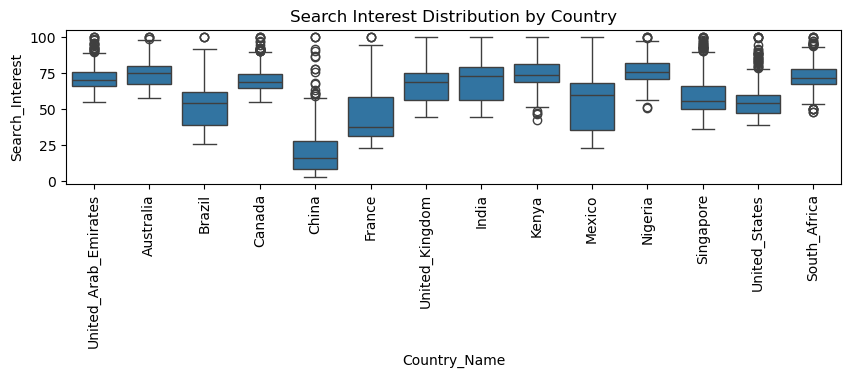

In [177]:
# Search Interest by Country
plt.figure(figsize=(10,2))
sns.boxplot(x='Country_Name', y='Search_Interest', data=df1)
plt.xticks(rotation=90)
plt.title("Search Interest Distribution by Country")
plt.show()


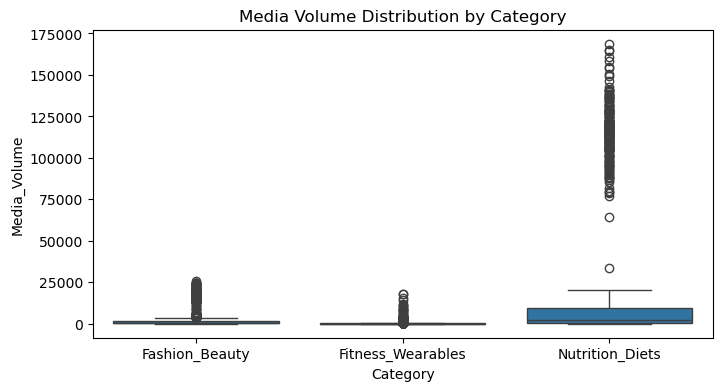

In [175]:
#  Media Volume by Category
plt.figure(figsize=(8,4))
sns.boxplot(x='Category', y='Media_Volume', data=df1)
plt.title("Media Volume Distribution by Category")
plt.show()

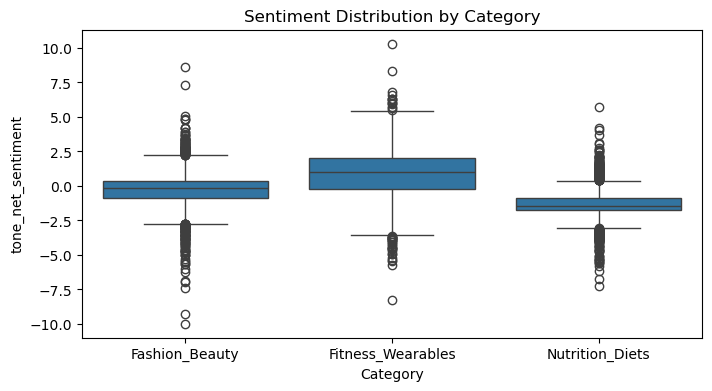

In [179]:
# Sentiment vs Category
plt.figure(figsize=(8,4))
sns.boxplot(x='Category', y='tone_net_sentiment', data=df1)
plt.title("Sentiment Distribution by Category")
plt.show()


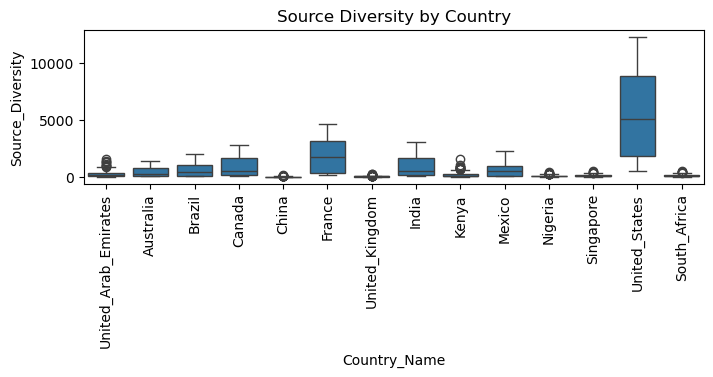

In [173]:
# Source Diversity vs Country
plt.figure(figsize=(8,2))
sns.boxplot(x='Country_Name', y='Source_Diversity', data=df1)
plt.xticks(rotation=90)
plt.title("Source Diversity by Country")
plt.show()

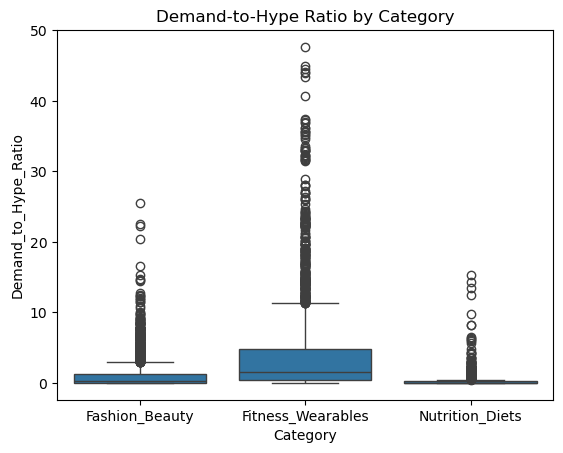

In [157]:
# Demand-to-Hype Ratio vs Category
sns.boxplot(x='Category', y='Demand_to_Hype_Ratio', data=df1)
plt.title("Demand-to-Hype Ratio by Category")
plt.show()

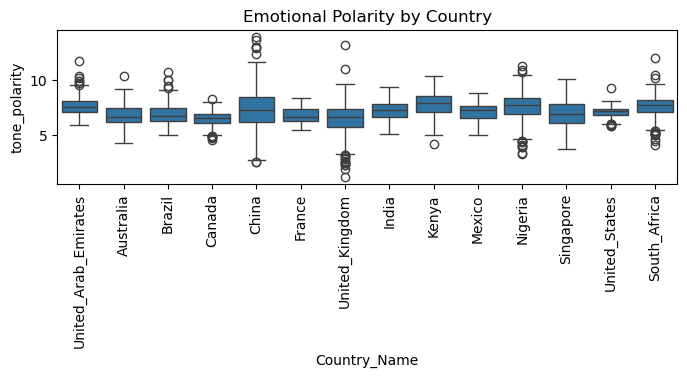

In [172]:
# Emotional Tone vs Country
plt.figure(figsize=(8,2))
sns.boxplot(x='Country_Name', y='tone_polarity', data=df1)
plt.xticks(rotation=90)
plt.title("Emotional Polarity by Country")
plt.show()


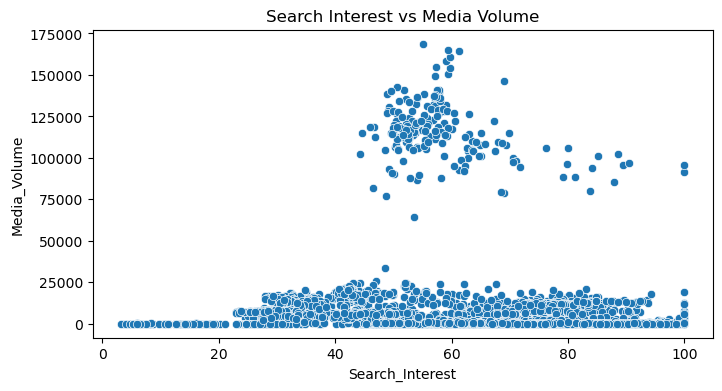

In [169]:
# Seach Interest vs Media Volume
plt.figure(figsize=(8,4))
sns.scatterplot(x='Search_Interest', y='Media_Volume', data=df1)
plt.title("Search Interest vs Media Volume")
plt.show()

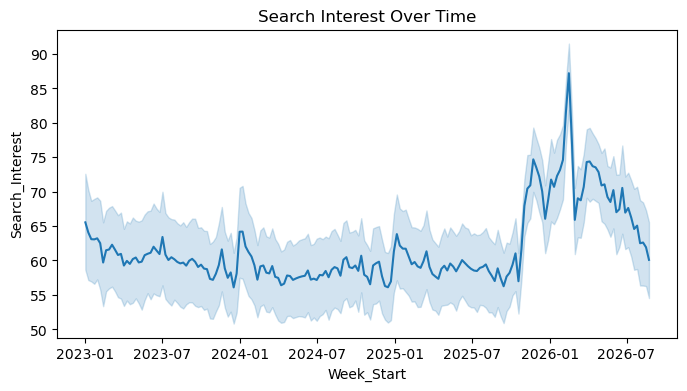

In [168]:
# time series analysis of Search Interest
plt.figure(figsize=(8,4))
sns.lineplot(x='Week_Start', y='Search_Interest', data=df1)
plt.title("Search Interest Over Time")
plt.show()

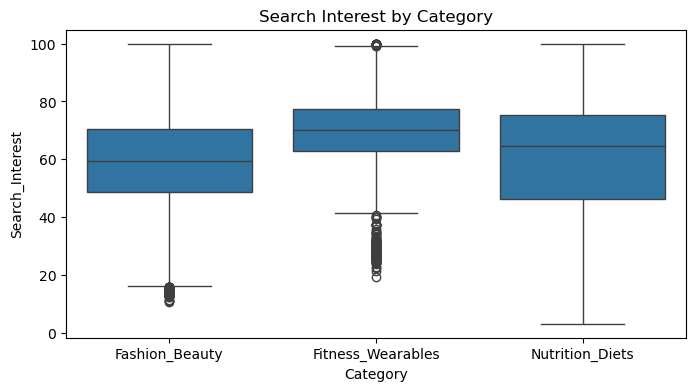

In [178]:
# categories vs Search Interest
plt.figure(figsize=(8,4))
sns.boxplot(x='Category', y='Search_Interest', data=df1)
plt.title("Search Interest by Category")
plt.show()


# 📊 Exploratory Data Analysis — Insights

---

## 📊 Univariate Analysis Insights

### 🔎 1. Public Search & Interest

🔵 **Search Interest**
- Average search interest remains relatively high at around **62–66 / 100**.
- Values range from **3 to 100**, showing that public attention can change significantly.
- 👉 **What it means:** People generally show strong interest, but major events can create sudden spikes.

🟠 **Search Velocity**
- Search velocity can change substantially from week to week.
- However, its average is close to zero.
- 👉 **What it means:** Search interest does not continuously move in one direction; increases and decreases tend to balance out over time.

🟣 **Search Acceleration**
- Search acceleration has a wide range, indicating that the speed of change itself can vary considerably.
- 👉 **What it means:** Some periods experience sudden changes in search momentum, which may indicate emerging trends or events.

### 💡 What It Means

Public interest is generally strong, but **short-term attention can change rapidly when new events or trends appear**.

### ✅ Takeaway

> 🎯 **Public interest is strong overall, but major events can cause sharp short-term changes in attention.**

---

### 📰 2. News & Media Coverage

🔴 **Media Volume**
- Typical weeks contain around **282 articles**, while major events can generate more than **168,000 articles**.
- The large difference between typical and extreme values significantly increases the average media volume.
- 👉 **What it means:** Media coverage is usually moderate but can become extremely large during major events.

🔵 **Source Diversity**
- A typical period contains around **146 publishers**.
- During major events, coverage can expand to more than **12,000 sources**.
- 👉 **What it means:** Important events can quickly attract attention from a very large number of publishers.

### 💡 What It Means

Media coverage is highly **event-driven**, with occasional major events creating extremely large increases in both article volume and publisher participation.

### ✅ Takeaway

> 📰 **Media coverage is usually moderate, but major events can create explosive increases in both articles and participating news sources.**

---

### 💬 3. Media Mood & Tone

🟠 **Net Sentiment**
- Average net sentiment is slightly negative at around **-0.22**.
- 👉 **What it means:** Media coverage tends to lean slightly more negative than positive overall.

🟣 **Positive & Negative Tone**
- Positive and negative tone scores are relatively close, with negative tone slightly higher on average.
- 👉 **What it means:** Coverage contains both favorable and unfavorable language, with a small overall negative tendency.

🔴 **Tone Polarity**
- Tone polarity averages around **7%**, indicating that emotionally expressive language is present in the coverage.
- 👉 **What it means:** News coverage is not completely neutral and contains measurable emotional language.

🔵 **Activity Density**
- Around **21%** of the content is associated with activity or event-oriented language.
- 👉 **What it means:** A meaningful portion of coverage focuses on actions, events, or activities.

🟢 **Self/Group Density**
- Self/group-oriented language remains below **1%**.
- 👉 **What it means:** References to people or groups are relatively limited compared with the overall amount of content.

### 💡 What It Means

The media environment is **slightly negative and contains noticeable emotional and event-oriented language**, while self/group references remain relatively limited.

### ✅ Takeaway

> 💬 **Media coverage is slightly negative overall, with noticeable emotional and event-focused language.**

---

### ⚖️ 4. Demand vs. Media Hype

🟠 **Demand-to-Hype Ratio**
- The median ratio is around **0.24**, meaning media coverage generally exceeds search demand.
- During some periods, the ratio rises dramatically, reaching around **47×**.
- 👉 **What it means:** Most of the time, media attention is stronger than search demand, but occasional periods show unusually strong public interest.

🔵 **Media Volume per Source**
- A typical publisher produces around **2–3 articles** per topic per week.
- 👉 **What it means:** Although total coverage can become very large, the typical number of articles per source remains relatively limited.

🟣 **Interest per Source**
- Median interest per source is around **0.44**.
- 👉 **What it means:** Search demand is generally small relative to the number of sources participating in coverage.

### 💡 What It Means

Media attention often grows faster than consumer search demand, although some periods show the opposite pattern.

### ✅ Takeaway

> ⚖️ **Media coverage usually exceeds public search demand, but occasional periods reveal strong consumer interest that is not matched by media coverage.**

---

## 🏆 Univariate Analysis — Overall Takeaway

🔵 **Public Interest** → Strong overall, but changes sharply during major events.

📰 **Media Coverage** → Usually moderate, but can increase dramatically during major events.

💬 **Media Tone** → Slightly negative with noticeable emotional and event-oriented language.

🌐 **Source Participation** → Broadens substantially when major events attract widespread coverage.

⚖️ **Demand vs. Hype** → Media attention generally exceeds search demand, but important exceptions exist.

> 🚀 **Overall Insight:** **Public interest is relatively strong, while media attention is much more event-driven and can grow far beyond the level of consumer demand.**

---

# 📊 Bivariate & Correlation Analysis Insights

> **Correlation guide:**  
> 🟢 Strong relationship → |r| ≥ 0.70  
> 🟡 Moderate relationship → 0.30 ≤ |r| < 0.70  
> 🔵 Weak relationship → 0.10 ≤ |r| < 0.30  
> ⚪ Very weak / negligible → |r| < 0.10

---

## 🔎 1. Consumer Demand & Search Momentum

🔵 **Search Interest ↔ Search Velocity | r = 0.131**
- Shows a weak positive relationship.
- 👉 **What it means:** Higher current search interest is only slightly associated with faster changes in search interest.

⚪ **Search Interest ↔ Search Acceleration | r = 0.006**
- Shows virtually no linear relationship.
- 👉 **What it means:** Knowing the current interest level does not tell us whether search momentum is accelerating.

🟢 **Search Velocity ↔ Search Acceleration | r = 0.721**
- Shows a strong positive relationship.
- 👉 **What it means:** Faster changes in search interest tend to occur alongside stronger changes in momentum.

### 💡 What It Means

Search Interest, Velocity, and Acceleration measure **different aspects of consumer demand**. Current interest does not necessarily indicate how quickly that interest is changing.

### ✅ Takeaway

> 🔎 **Current demand level and demand momentum are different signals, so both should be monitored when identifying emerging trends.**

---

## 📰 2. Consumer Demand vs. Media Coverage

⚪ **Search Interest ↔ Media Volume | r = -0.094**
- Shows almost no linear relationship.
- 👉 **What it means:** More people searching does not necessarily mean more articles are being published.

🔵 **Search Interest ↔ Source Diversity | r = -0.194**
- Shows a weak negative relationship.
- 👉 **What it means:** Higher search interest is slightly associated with fewer participating sources.

🔵 **Search Interest ↔ Media Volume per Source | r = -0.139**
- Shows a weak negative relationship.
- 👉 **What it means:** Higher search interest does not necessarily lead each publisher to produce more articles.

⚪ **Search Interest ↔ Interest per Source | r = 0.083**
- Shows almost no linear relationship.
- 👉 **What it means:** Overall search interest and search interest relative to source participation behave differently.

### 💡 What It Means

Consumer demand and media coverage appear to be **largely independent of each other** in this dataset.

### ✅ Takeaway

> 📰 **High public interest does not automatically result in high media coverage, and high media coverage does not necessarily indicate high public interest.**

---

## 💬 3. Consumer Demand & Media Sentiment

🟢 **Search Interest ↔ Positive Score | r = 0.251**
- Shows a weak positive relationship.
- 👉 **What it means:** Higher search interest tends to occur alongside slightly more positive media tone.

🔵 **Search Interest ↔ Net Sentiment | r = 0.223**
- Shows a weak positive relationship.
- 👉 **What it means:** More favorable media sentiment is associated with somewhat higher search interest.

🔵 **Search Interest ↔ Negative Score | r = -0.157**
- Shows a weak negative relationship.
- 👉 **What it means:** Higher search interest tends to occur alongside slightly lower negative tone.

⚪ **Search Interest ↔ Tone Polarity | r = 0.006**
- Shows virtually no relationship.
- 👉 **What it means:** The emotional intensity of coverage does not appear to explain overall search interest.

### 💡 What It Means

Search interest has a **slightly stronger relationship with positive media tone than negative tone**, although all relationships are relatively weak.

### ✅ Takeaway

> 💬 **More positive media coverage tends to coincide with slightly higher public interest, but sentiment alone does not strongly explain demand.**

---

## ⏱️ 4. Search Momentum vs. Media & Sentiment

⚪ **Search Velocity ↔ Media Volume | r = -0.005**
- Virtually no relationship.
- 👉 Changes in search interest do not correspond directly to changes in article volume.

⚪ **Search Velocity ↔ Net Sentiment | r = 0.017**
- Virtually no relationship.
- 👉 Changes in search interest are not strongly associated with changes in overall media sentiment.

⚪ **Search Velocity ↔ Positive Score | r = 0.021**
- Virtually no relationship.
- 👉 Positive media tone does not explain short-term changes in search velocity.

⚪ **Search Velocity ↔ Negative Score | r = -0.011**
- Virtually no relationship.
- 👉 Negative media tone does not explain short-term search momentum.

⚪ **Search Acceleration ↔ Media Volume | r = -0.003**
- Virtually no relationship.
- 👉 Sudden changes in search momentum are not directly associated with media volume.

⚪ **Search Acceleration ↔ Net Sentiment | r = -0.001**
- Virtually no relationship.
- 👉 Changes in search acceleration are not explained by overall media sentiment.

### 💡 What It Means

Short-term changes in consumer search behavior appear to be **largely independent of media volume and sentiment**.

### ✅ Takeaway

> ⏱️ **Media coverage and sentiment do not strongly explain short-term changes in consumer search momentum.**

---

## 🌐 5. Media Volume & Source Breadth

🟢 **Media Volume ↔ Source Diversity | r = 0.915**
- Shows a very strong positive relationship.
- 👉 More articles are strongly associated with participation from more publishers.

🟢 **Media Volume ↔ Media Volume per Source | r = 0.782**
- Shows a strong positive relationship.
- 👉 Higher total coverage is associated with more articles being produced per source.

🔵 **Media Volume ↔ Negative Score | r = 0.172**
- Shows a weak positive relationship.
- 👉 Larger amounts of coverage are slightly associated with more negative tone.

🔵 **Media Volume ↔ Net Sentiment | r = -0.197**
- Shows a weak negative relationship.
- 👉 Heavier coverage tends to be slightly less favorable in tone.

🔵 **Media Volume ↔ Positive Score | r = -0.171**
- Shows a weak negative relationship.
- 👉 More coverage is slightly associated with lower positive tone.

🔵 **Media Volume ↔ Activity Density | r = 0.156**
- Shows a weak positive relationship.
- 👉 Heavier coverage tends to contain somewhat more activity-oriented language.

🔵 **Media Volume ↔ Self/Group Density | r = 0.120**
- Shows a weak positive relationship.
- 👉 Higher coverage is slightly associated with more self/group-oriented language.

### 💡 What It Means

Large increases in media coverage are strongly associated with **broader publisher participation**, but not necessarily with more positive reporting.

### ✅ Takeaway

> 🌐 **When media coverage grows, participation expands across more publishers, but the overall tone does not necessarily become more positive.**

---

## ⚖️ 6. Media Volume vs. Demand-to-Hype

🔵 **Media Volume ↔ Demand-to-Hype Ratio | r = -0.113**
- Shows a weak negative relationship.
- 👉 As media coverage increases, demand becomes slightly smaller relative to the amount of coverage.

🔵 **Media Volume ↔ Interest per Source | r = -0.100**
- Shows a weak negative relationship.
- 👉 More media coverage is slightly associated with lower search interest per source.

### 💡 What It Means

Large amounts of media coverage do not necessarily represent equally strong consumer demand.

### ✅ Takeaway

> ⚖️ **More media coverage does not automatically mean more consumer demand; coverage can grow faster than public interest.**

---

## 💫 7. Net Sentiment & Media Tone

🟢 **Net Sentiment ↔ Positive Score | r = 0.793**
- Shows a strong positive relationship.
- 👉 Higher positive tone is strongly associated with higher net sentiment.

🔴 **Net Sentiment ↔ Negative Score | r = -0.919**
- Shows a very strong negative relationship.
- 👉 Higher negative tone is strongly associated with lower net sentiment.

🟠 **Net Sentiment ↔ Tone Polarity | r = -0.457**
- Shows a moderate negative relationship.
- 👉 Higher polarity values are associated with lower net sentiment in this dataset.

🔵 **Net Sentiment ↔ Activity Density | r = -0.119**
- Shows a weak negative relationship.
- 👉 More activity-oriented language is slightly associated with less favorable sentiment.

🔵 **Net Sentiment ↔ Source Diversity | r = -0.257**
- Shows a weak negative relationship.
- 👉 Broader source participation is slightly associated with less favorable overall sentiment.

### 💡 What It Means

Positive and negative tone are closely connected to net sentiment, which is expected because these measures describe related aspects of media tone.

### ✅ Takeaway

> 💫 **Media tone strongly influences net sentiment, with negative tone showing the strongest relationship with overall sentiment.**

---

## 🎭 8. Positive vs. Negative Media Tone

🟠 **Positive Score ↔ Negative Score | r = -0.488**
- Shows a moderate negative relationship.
- 👉 More positive tone tends to occur alongside less negative tone.

🔵 **Positive Score ↔ Tone Polarity | r = 0.180**
- Shows a weak positive relationship.
- 👉 Positive tone has only a limited relationship with polarity.

🟢 **Negative Score ↔ Tone Polarity | r = 0.771**
- Shows a strong positive relationship.
- 👉 Negative tone is strongly associated with changes in tone polarity in this dataset.

⚠️ **Important Check**
- The positive relationship between `tone_negative_score` and `tone_polarity` may seem unexpected depending on how `tone_polarity` was calculated.
- 👉 **Verify the definition and formula of `tone_polarity` before using this relationship as a business conclusion.**

### 💡 What It Means

Positive and negative tone move in different directions, while the relationship between negative tone and polarity deserves additional validation.

### ✅ Takeaway

> 🎭 **Positive and negative media tone are related but distinct signals, and the polarity calculation should be verified before drawing strong conclusions.**

---

## 📈 9. Media Activity Density

🟡 **Activity Density ↔ Source Diversity | r = 0.212**
- Shows a weak positive relationship.
- 👉 More diverse coverage is slightly associated with more activity-oriented language.

🔵 **Activity Density ↔ Demand-to-Hype Ratio | r = -0.287**
- Shows a weak negative relationship.
- 👉 Higher media activity is associated with slightly lower consumer demand relative to coverage.

🔵 **Activity Density ↔ Media Volume per Source | r = 0.254**
- Shows a weak positive relationship.
- 👉 More active coverage tends to involve slightly more articles per publisher.

🔵 **Activity Density ↔ Interest per Source | r = -0.278**
- Shows a weak negative relationship.
- 👉 Higher media activity tends to occur alongside slightly lower search interest per source.

### 💡 What It Means

More active media environments do not necessarily indicate stronger consumer demand.

### ✅ Takeaway

> 📈 **Higher media activity may reflect increased coverage intensity rather than stronger consumer demand.**

---

## 👥 10. Self/Group Media Language

🔵 **Self/Group Density ↔ Source Diversity | r = 0.153**
- Shows a weak positive relationship.
- 👉 More diverse coverage is slightly associated with more self/group-oriented language.

⚪ **Self/Group Density ↔ Demand-to-Hype Ratio | r = 0.033**
- Shows virtually no relationship.
- 👉 Self/group language does not meaningfully relate to demand compared with media coverage.

⚪ **Self/Group Density ↔ Interest per Source | r = 0.034**
- Shows virtually no relationship.
- 👉 Self/group language does not meaningfully relate to search interest per source.

### 💡 What It Means

Self/group-oriented language appears largely independent of consumer demand and the demand-to-hype relationship.

### ✅ Takeaway

> 👥 **Self/group language provides little information about consumer demand or media hype in this dataset.**

---

## 🟣 11. Demand-to-Hype & Interest per Source

🟢 **Demand-to-Hype Ratio ↔ Interest per Source | r = 0.963**
- Shows an extremely strong positive relationship.
- 👉 The two measures move almost identically.

⚠️ **Feature Engineering Finding**
- This extremely high correlation suggests that these two variables contain substantial overlapping information.
- 👉 They may be measuring very similar underlying behavior.

🔵 **Demand-to-Hype Ratio ↔ Negative Score | r = -0.332**
- Shows a moderate negative relationship.
- 👉 Higher negative tone tends to occur when public demand is lower relative to media coverage.

🟡 **Demand-to-Hype Ratio ↔ Net Sentiment | r = 0.316**
- Shows a moderate positive relationship.
- 👉 More favorable sentiment tends to coincide with stronger demand relative to media coverage.

🔵 **Demand-to-Hype Ratio ↔ Activity Density | r = -0.287**
- Shows a weak negative relationship.
- 👉 More active media coverage tends to coincide with a lower demand-to-hype ratio.

🔵 **Demand-to-Hype Ratio ↔ Tone Polarity | r = -0.238**
- Shows a weak negative relationship.
- 👉 Higher polarity is slightly associated with lower demand relative to media coverage.

### 💡 What It Means

Public demand appears relatively stronger when media sentiment is more favorable and weaker when negative or highly active coverage increases.

### ✅ Takeaway

> ⚖️ **Demand is relatively stronger when coverage is more favorable, while heavier negative or highly active coverage tends to increase the gap between media attention and public demand.**

---

## 🎯 12. Interest per Source

🟢 **Interest per Source ↔ Negative Score | r = -0.307**
- Shows a moderate negative relationship.
- 👉 Higher negative tone tends to occur alongside lower search interest per source.

🟡 **Interest per Source ↔ Net Sentiment | r = 0.283**
- Shows a weak positive relationship.
- 👉 More favorable sentiment is associated with somewhat higher interest per source.

🔵 **Interest per Source ↔ Activity Density | r = -0.278**
- Shows a weak negative relationship.
- 👉 More active media coverage tends to coincide with lower interest per source.

🔵 **Interest per Source ↔ Tone Polarity | r = -0.235**
- Shows a weak negative relationship.
- 👉 Higher polarity is slightly associated with lower interest per source.

### 💡 What It Means

Interest per source appears more favorable when sentiment is positive and weaker when media coverage becomes more negative or highly active.

### ✅ Takeaway

> 🎯 **Search interest per source tends to be stronger with favorable media tone and weaker when negative media activity increases.**

---

### ⚠️ Modeling Consideration

Before using all these variables together in a machine-learning model:

- 🔍 Check **VIF (Variance Inflation Factor)**.
- 🧮 Check whether one feature is mathematically derived from another.
- 🗑️ Consider removing redundant variables when appropriate.
- 🧪 Compare model performance with and without highly correlated features.
- 📊 Keep features that provide unique predictive information.

### ✅ Takeaway

> ⚠️ **Several engineered features contain overlapping information, so feature selection should be performed before machine-learning modeling to reduce unnecessary multicollinearity.**

---

# 🏆 Overall Correlation Analysis — Business Insights

### 🔎 Key Patterns

🔵 **Consumer Demand**
- Search interest has weak relationships with most media variables.
- 👉 Public demand cannot be explained simply by media volume.

📰 **Media Coverage**
- Media volume has a very strong relationship with source diversity.
- 👉 More coverage usually means more publishers are participating.

💬 **Media Sentiment**
- Positive and negative tone are strongly related to overall net sentiment.
- 👉 Media tone is an important part of the overall sentiment picture.

⚖️ **Demand vs. Hype**
- Demand-to-hype has almost no relationship with total media volume.
- 👉 More articles do not automatically mean more public demand.

🟣 **Feature Relationships**
- Several engineered variables have very high correlations.
- 👉 Some features may contain overlapping information.

### 🏆 Final Business Takeaway

> 🚀 **The data suggests that public demand and media attention are not the same thing: media coverage can expand dramatically without a matching increase in consumer interest. At the same time, broader publisher participation strongly increases media volume, while media sentiment has a meaningful relationship with consumer demand.**